In [1]:
import numpy as np
from numba import njit, prange





In [16]:
# implement regular matrix multiply

@njit(parallel=True)
def dumbmatmul(A, B):
    m, n = A.shape
    n, p = B.shape
    C = np.zeros((m, p))
    for k in prange(n):
        for i in range(m):
            for j in range(p):
                C[i, j] += A[i, k] * B[k, j]
    return C

# compile 
A = np.random.rand(128, 128)
B = np.random.rand(128, 128)
C = dumbmatmul(A, B)



In [33]:
%%time
C = dumbmatmul(A, B)

CPU times: total: 0 ns
Wall time: 7 ms


In [6]:
%%time

a = np.dot(A, B)

CPU times: total: 219 ms
Wall time: 38.1 ms


In [3]:
from numba import njit, prange
import numpy as np

In [5]:
@njit(parallel=True)
# @njit()
def strassen(A, B, cutoff=128):
    a, b = A.shape
    _, c = B.shape    
    
    if a <= cutoff:
        # do regular matrix multiplication manually
        C = np.zeros((a, c))
        for k in prange(b):
            for i in range(a):
                for j in range(c):
                    C[i, j] += A[i, k] * B[k, j]
        return C

    # split matrices into quarters
    a, b = a // 2, b // 2
    A11, A12 = A[:a, :b], A[:a, b:]
    A21, A22 = A[a:, :b], A[a:, b:]
    B11, B12 = B[:b, :b], B[:b, b:]
    B21, B22 = B[b:, :b], B[b:, b:]

    # compute products
    P1 = strassen(A11 + A22, B11 + B22, cutoff)
    P2 = strassen(A21 + A22, B11, cutoff)
    P3 = strassen(A11, B12 - B22, cutoff)
    P4 = strassen(A22, B21 - B11, cutoff)
    P5 = strassen(A11 + A12, B22, cutoff)
    P6 = strassen(A21 - A11, B11 + B12, cutoff)
    P7 = strassen(A12 - A22, B21 + B22, cutoff)

    # compute products
    C11 = P1 + P4 - P5 + P7
    C12 = P3 + P5
    C21 = P2 + P4
    C22 = P1 - P2 + P3 + P6

    # combine products
    C = np.zeros((2 * a, 2 * b))
    C[:a, :b] = C11
    C[:a, b:] = C12
    C[a:, :b] = C21
    C[a:, b:] = C22

    return C
    
A, B = np.random.rand(4, 4), np.random.rand(4, 4)
compile = strassen(A, B)
print((compile - A@B < 0.001).all())

True


In [6]:
import numpy as np
N = 1024
A = np.random.rand(N, N)
B = np.random.rand(N, N)

In [33]:
7**4

2401

In [34]:
8**4

4096

In [7]:
# print((A@B - strassen(A, B) < 0.00001).all())

In [36]:
%%time
A@B

CPU times: total: 78.1 ms
Wall time: 24 ms


array([[250.62129495, 249.34160609, 257.08080862, ..., 246.03220709,
        256.42227818, 251.17587646],
       [257.11590195, 256.90190813, 255.85133895, ..., 252.10486518,
        257.80874822, 259.21661828],
       [259.51617597, 264.25185003, 262.50027335, ..., 258.82171799,
        265.49104815, 262.04697596],
       ...,
       [253.6925408 , 256.07461798, 258.47558858, ..., 247.92903494,
        261.37683602, 256.21375883],
       [260.65412265, 260.81874385, 264.78555516, ..., 258.11087758,
        263.47193381, 267.1586559 ],
       [261.24796876, 259.09289231, 261.02378564, ..., 248.69311164,
        259.75414978, 256.91683584]])

In [35]:
%%time
c = strassen(A, B)

CPU times: total: 2.12 s
Wall time: 296 ms


In [23]:
import time 

tn = []
ts = []
N = 4096

A = np.random.rand(N, N)
B = np.random.rand(N, N)

for i in range(6, int(np.log2(N))-1):
    cutoff = 2**i

    t1 = time.time()
    c = strassen(A, B, cutoff=cutoff)
    t2 = time.time()

    ts.append(t2 - t1)

    print(f"Matrix size: {N}x{N}, cutoff = {cutoff}")
    print(f"Time for strassen algorithm: {t2 - t1}")
    print("")

# 1024 really likes 64 cutoff non parallel at around 0.4s
# 1024 really likes 512 cutoff parallel at around 0.1s
# 4096 really likes 128 cutoff non parallel at around 21s (O(N**3.7) shit scaling)
# 4096 really likes 512 cutoff parallel at around 5.7s (shit scaling as always)

Matrix size: 4096x4096, cutoff = 64
Time for strassen algorithm: 51.89958071708679

Matrix size: 4096x4096, cutoff = 128
Time for strassen algorithm: 10.961318254470825

Matrix size: 4096x4096, cutoff = 256
Time for strassen algorithm: 7.054391622543335

Matrix size: 4096x4096, cutoff = 512
Time for strassen algorithm: 5.71353006362915

Matrix size: 4096x4096, cutoff = 1024
Time for strassen algorithm: 9.958733081817627



In [40]:

N = 2048

A = np.random.rand(N, N)
B = np.random.rand(N, N)

In [13]:
%%time

# print(((A @ B) - strassen(A, B, cutoff=2) < 0.001).mean())

CPU times: total: 0 ns
Wall time: 0 ns


In [32]:
np.log2(384)/2 # log4

4.292481250360578

the number of parallel executions must be lower than the number of cores <br>
to know how many divisions you need:

## divs = Log4(cores).floor()

6 cores = 4 cores = 4^1 = 1 division <br>
384 cores = 256 cores = 4^4 = 4 divisions

# cutoff must be N/(2**divs)

In [41]:
%%time
A@B

CPU times: total: 1.2 s
Wall time: 134 ms


array([[532.24744273, 508.64486272, 503.35900133, ..., 524.44904879,
        521.20416121, 507.58968259],
       [511.48392374, 502.72210727, 485.46063967, ..., 511.057585  ,
        504.34193715, 505.38677891],
       [527.2267327 , 509.81509103, 494.73165522, ..., 518.31670691,
        512.95230194, 509.90957053],
       ...,
       [531.82371545, 506.83138374, 498.68062378, ..., 525.84453608,
        518.11824774, 501.75522289],
       [535.87491691, 525.27042019, 506.99505707, ..., 526.21144679,
        523.62284382, 517.75066178],
       [530.6842535 , 511.19808223, 502.40452568, ..., 519.99817151,
        518.89199941, 510.53115739]])

In [48]:
%%time
strassen(A, B, cutoff=512).shape

CPU times: total: 10 s
Wall time: 1.26 s


(2048, 2048)

In [45]:
%%time
dumbmatmul(A, B).shape

CPU times: total: 43.8 s
Wall time: 5.44 s


(2048, 2048)

In [28]:
c

array([[ 839.94269627,  812.23700441,  804.02558487, ...,  969.83206956,
         986.02960047,  976.34134738],
       [1027.37071075, 1053.73978425, 1073.55763356, ...,  949.8653234 ,
         962.467779  ,  939.21924102],
       [ 946.50997716,  923.86037303,  952.44662091, ...,  981.93512607,
         982.42350159,  973.60307698],
       ...,
       [ 945.30215125,  907.15432123,  935.0685841 , ...,  761.32259821,
         717.55340567,  756.40222559],
       [ 936.15286376,  933.28653366,  921.33506034, ...,  791.74002622,
         809.49434317,  797.78944478],
       [ 927.2032459 ,  937.98815464,  962.14313508, ...,  834.91555179,
         780.99217026,  842.20399686]])

In [21]:
np.log2(21/0.4/4)

3.7142455176661224

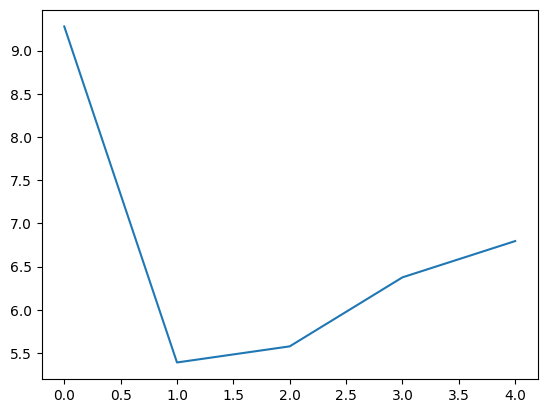

In [39]:
import matplotlib.pyplot as plt
plt.plot(ts)

In [49]:
import time 

tn = []
ts = []

for i in range(2, 12):
    N = 2**i
    A = np.random.rand(N, N)
    B = np.random.rand(N, N)
    t0 = time.time()
    c = A@B
    t1 = time.time()
    c = strassen(A, B)
    t2 = time.time()

    tn.append(t1 - t0)
    ts.append(t2 - t1)

    print(f"Matrix size: {N}x{N}")
    print(f"Time for regular matrix multiplication: {t1 - t0}")
    print(f"Time for strassen algorithm: {t2 - t1}")
    print("")

Matrix size: 4x4
Time for regular matrix multiplication: 0.0
Time for strassen algorithm: 0.0

Matrix size: 8x8
Time for regular matrix multiplication: 0.0
Time for strassen algorithm: 0.0

Matrix size: 16x16
Time for regular matrix multiplication: 0.0
Time for strassen algorithm: 0.0

Matrix size: 32x32
Time for regular matrix multiplication: 0.0
Time for strassen algorithm: 0.004132509231567383

Matrix size: 64x64
Time for regular matrix multiplication: 0.0
Time for strassen algorithm: 0.012799978256225586

Matrix size: 128x128
Time for regular matrix multiplication: 0.0
Time for strassen algorithm: 0.08171367645263672

Matrix size: 256x256
Time for regular matrix multiplication: 0.0
Time for strassen algorithm: 0.47177672386169434

Matrix size: 512x512
Time for regular matrix multiplication: 0.009509563446044922
Time for strassen algorithm: 3.3996028900146484

Matrix size: 1024x1024
Time for regular matrix multiplication: 0.035782575607299805
Time for strassen algorithm: 16.23981428

In [50]:
import matplotlib.pyplot as plt

plt.plot(2**np.arange(2, 10), tn/2**np.arange(2, 10), label="Regular matrix multiplication")
plt.plot(2**np.arange(2, 10), ts/2**np.arange(2, 10), label="Strassen algorithm")

ValueError: operands could not be broadcast together with shapes (10,) (8,) 

In [29]:
%%time
import math
from typing import List, Tuple
 
 
def default_matrix_multiplication(a: List, b: List) -> List:
    """
    Multiplication only for 2x2 matrices
    """
    if len(a) != 2 or len(a[0]) != 2 or len(b) != 2 or len(b[0]) != 2:
        raise Exception("Matrices are not 2x2")
    new_matrix = [
        [a[0][0] * b[0][0] + a[0][1] * b[1][0], a[0][0] * b[0][1] + a[0][1] * b[1][1]],
        [a[1][0] * b[0][0] + a[1][1] * b[1][0], a[1][0] * b[0][1] + a[1][1] * b[1][1]],
    ]
    return new_matrix
 
 
def matrix_addition(matrix_a: List, matrix_b: List):
    return [
        [matrix_a[row][col] + matrix_b[row][col] for col in range(len(matrix_a[row]))]
        for row in range(len(matrix_a))
    ]
 
 
def matrix_subtraction(matrix_a: List, matrix_b: List):
    return [
        [matrix_a[row][col] - matrix_b[row][col] for col in range(len(matrix_a[row]))]
        for row in range(len(matrix_a))
    ]
 
 
def split_matrix(a: List,) -> Tuple[List, List, List, List]:
    """
    Given an even length matrix, returns the top_left, top_right, bot_left, bot_right
    quadrant.
 
    >>> split_matrix([[4,3,2,4],[2,3,1,1],[6,5,4,3],[8,4,1,6]])
    ([[4, 3], [2, 3]], [[2, 4], [1, 1]], [[6, 5], [8, 4]], [[4, 3], [1, 6]])
    >>> split_matrix([
    ...     [4,3,2,4,4,3,2,4],[2,3,1,1,2,3,1,1],[6,5,4,3,6,5,4,3],[8,4,1,6,8,4,1,6],
    ...     [4,3,2,4,4,3,2,4],[2,3,1,1,2,3,1,1],[6,5,4,3,6,5,4,3],[8,4,1,6,8,4,1,6]
    ... ])  # doctest: +NORMALIZE_WHITESPACE
    ([[4, 3, 2, 4], [2, 3, 1, 1], [6, 5, 4, 3], [8, 4, 1, 6]], [[4, 3, 2, 4],
      [2, 3, 1, 1], [6, 5, 4, 3], [8, 4, 1, 6]], [[4, 3, 2, 4], [2, 3, 1, 1],
      [6, 5, 4, 3], [8, 4, 1, 6]], [[4, 3, 2, 4], [2, 3, 1, 1], [6, 5, 4, 3],
      [8, 4, 1, 6]])
    """
    if len(a) % 2 != 0 or len(a[0]) % 2 != 0:
        raise Exception("Odd matrices are not supported!")
 
    matrix_length = len(a)
    mid = matrix_length // 2
 
    top_right = [[a[i][j] for j in range(mid, matrix_length)] for i in range(mid)]
    bot_right = [
        [a[i][j] for j in range(mid, matrix_length)] for i in range(mid, matrix_length)
    ]
 
    top_left = [[a[i][j] for j in range(mid)] for i in range(mid)]
    bot_left = [[a[i][j] for j in range(mid)] for i in range(mid, matrix_length)]
 
    return top_left, top_right, bot_left, bot_right
 
 
def matrix_dimensions(matrix: List) -> Tuple[int, int]:
    return len(matrix), len(matrix[0])
 
 
def print_matrix(matrix: List) -> None:
    for i in range(len(matrix)):
        print(matrix[i])
 
 
def actual_strassen(matrix_a: List, matrix_b: List) -> List:
    """
    Recursive function to calculate the product of two matrices, using the Strassen
    Algorithm.  It only supports even length matrices.
    """
    if matrix_dimensions(matrix_a) == (2, 2):
        return default_matrix_multiplication(matrix_a, matrix_b)
 
    a, b, c, d = split_matrix(matrix_a)
    e, f, g, h = split_matrix(matrix_b)
 
    t1 = actual_strassen(a, matrix_subtraction(f, h))
    t2 = actual_strassen(matrix_addition(a, b), h)
    t3 = actual_strassen(matrix_addition(c, d), e)
    t4 = actual_strassen(d, matrix_subtraction(g, e))
    t5 = actual_strassen(matrix_addition(a, d), matrix_addition(e, h))
    t6 = actual_strassen(matrix_subtraction(b, d), matrix_addition(g, h))
    t7 = actual_strassen(matrix_subtraction(a, c), matrix_addition(e, f))
 
    top_left = matrix_addition(matrix_subtraction(matrix_addition(t5, t4), t2), t6)
    top_right = matrix_addition(t1, t2)
    bot_left = matrix_addition(t3, t4)
    bot_right = matrix_subtraction(matrix_subtraction(matrix_addition(t1, t5), t3), t7)
 
    # construct the new matrix from our 4 quadrants
    new_matrix = []
    for i in range(len(top_right)):
        new_matrix.append(top_left[i] + top_right[i])
    for i in range(len(bot_right)):
        new_matrix.append(bot_left[i] + bot_right[i])
    return new_matrix
 
 
def strassen(matrix1: List, matrix2: List) -> List:
    """
    >>> strassen([[2,1,3],[3,4,6],[1,4,2],[7,6,7]], [[4,2,3,4],[2,1,1,1],[8,6,4,2]])
    [[34, 23, 19, 15], [68, 46, 37, 28], [28, 18, 15, 12], [96, 62, 55, 48]]
    >>> strassen([[3,7,5,6,9],[1,5,3,7,8],[1,4,4,5,7]], [[2,4],[5,2],[1,7],[5,5],[7,8]])
    [[139, 163], [121, 134], [100, 121]]
    """
    if matrix_dimensions(matrix1)[1] != matrix_dimensions(matrix2)[0]:
        raise Exception(
            f"Unable to multiply these matrices, please check the dimensions. \n"
            f"Matrix A:{matrix1} \nMatrix B:{matrix2}"
        )
    dimension1 = matrix_dimensions(matrix1)
    dimension2 = matrix_dimensions(matrix2)
 
    # if dimension1[0] == dimension1[1] and dimension2[0] == dimension2[1]:
    #     return matrix1, matrix2
 
    maximum = max(max(dimension1), max(dimension2))
    maxim = int(math.pow(2, math.ceil(math.log2(maximum))))
    new_matrix1 = matrix1
    new_matrix2 = matrix2
 
    # Adding zeros to the matrices so that the arrays dimensions are the same and also
    # power of 2
    for i in range(0, maxim):
        if i < dimension1[0]:
            for j in range(dimension1[1], maxim):
                new_matrix1[i].append(0)
        else:
            new_matrix1.append([0] * maxim)
        if i < dimension2[0]:
            for j in range(dimension2[1], maxim):
                new_matrix2[i].append(0)
        else:
            new_matrix2.append([0] * maxim)
 
    final_matrix = actual_strassen(new_matrix1, new_matrix2)
 
    # Removing the additional zeros
    for i in range(0, maxim):
        if i < dimension1[0]:
            for j in range(dimension2[1], maxim):
                final_matrix[i].pop()
        else:
            final_matrix.pop()
    return final_matrix
 
import time
if __name__ == "__main__":
    N = 128
    M = 128
    K = 128
    matrix1 = np.random.rand(M, N).tolist()
    matrix2 = np.random.rand(N, K).tolist()
    t0 = time.time()
    print(matrix_dimensions(strassen(matrix1, matrix2)))
    print(time.time() - t0)


(128, 128)
1.759077548980713
CPU times: total: 1.16 s
Wall time: 1.76 s


In [30]:
%%time
print(np.dot(matrix1, matrix2).shape)


(128, 128)
CPU times: total: 0 ns
Wall time: 7.76 ms
